In [1]:
# CELL 1: Setup & Imports
!pip install yfinance pandas-datareader statsmodels plotly -q
!pip install yfinance pandas-datareader statsmodels plotly seaborn kaleido -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

In [2]:
# CELL 2: Data Acquisition & Preprocessing
class FactorDataLoader:
    """Handles the downloading and alignment of Fama-French 5 factors and equity returns."""

    def __init__(self, start_date, end_date):
        self.start = start_date
        self.end = end_date

    def get_fama_french_factors(self):
        """Fetches FF 5-Factor daily data."""
        print("Fetching Fama-French Factors")
        try:
            ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', self.start, self.end)[0]

            # Convert pandas PeriodDtype to Timestamps
            ff5 = ff5.to_timestamp()

            # Force identical index formats
            ff5.index = pd.to_datetime(ff5.index).normalize()
            ff5.columns = ff5.columns.str.strip()
            ff5.rename(columns={'Mkt-RF': 'MKT'}, inplace=True)

            # Scale properly
            factors = ff5.dropna() / 100.0

            print(f"  -> FF Data loaded: {len(factors)} rows (From {factors.index.min().date()} to {factors.index.max().date()})")
            return factors

        except Exception as e:
            print(f"Error fetching FF data: {e}")
            return None

    def get_equity_returns(self, tickers):
        """Fetches daily adjusted close prices and calculates returns."""
        print(f"Fetching Equity Data for {tickers}")
        try:
            raw_data = yf.download(tickers, start=self.start, end=self.end, progress=False, auto_adjust=True)
            prices = raw_data['Close']

            if isinstance(prices, pd.Series):
                prices = prices.to_frame(tickers[0])

            # Strip timezones AND normalize to midnight (00:00:00)
            prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()

            returns = prices.pct_change().dropna()

            print(f"  -> Equity Data loaded: {len(returns)} rows (From {returns.index.min().date()} to {returns.index.max().date()})")
            return returns

        except Exception as e:
            print(f"Error fetching Equity data: {e}")
            return None

    def create_analysis_dataset(self, tickers):
        """Merges factors and returns into a single aligned dataframe."""
        factors = self.get_fama_french_factors()
        returns = self.get_equity_returns(tickers)

        if factors is None or returns is None:
            raise ValueError("Data fetching failed. Cannot proceed.")

        # Inner join to perfectly align dates
        data = returns.join(factors, how='inner')
        print(f"  -> Successfully joined data. Final shape: {data.shape}")
        return data

# Initialize the loader for the last 5 years
end_date = datetime.today()
start_date = end_date - timedelta(days=365 * 5)

loader = FactorDataLoader(start_date, end_date)
tickers = ['AAPL', 'JPM']
dataset = loader.create_analysis_dataset(tickers)

print("\nDataset Head:")
display(dataset.head())

Fetching Fama-French Factors
  -> FF Data loaded: 1228 rows (From 2021-08-09 to 2026-06-30)
Fetching Equity Data for ['AAPL', 'JPM']
  -> Equity Data loaded: 1254 rows (From 2021-08-10 to 2026-08-07)
  -> Successfully joined data. Final shape: (1227, 8)

Dataset Head:


,AAPL,JPM,MKT,SMB,HML,RMW,CMA,RF
Date,,,,,,,,
2021-08-10,-0.003354,0.012267,0.0006,0.0038,0.0182,0.0072,0.0092,0.0
2021-08-11,0.001785,0.011930,0.0020,0.0030,0.0144,0.0091,0.0056,0.0
2021-08-12,0.020773,0.003909,0.0024,-0.0068,-0.0041,0.0007,0.0011,0.0
2021-08-13,0.001410,-0.011187,0.0002,-0.0095,-0.0027,0.0070,-0.0001,0.0
2021-08-16,0.013548,-0.006564,-0.0003,-0.0086,0.0006,0.0166,0.0022,0.0


In [3]:
# CELL 3: Core Econometric Models (Static & Rolling OLS)
class FactorModeler:
    """Performs static and rolling OLS factor regressions."""

    def __init__(self, data, target_ticker, factors=['MKT', 'SMB', 'HML', 'RMW', 'CMA']):
        self.data = data.copy()
        self.target = target_ticker
        self.factors = factors

        # Calculate excess returns for the target asset
        self.data['Excess_Ret'] = self.data[self.target] - self.data['RF']

        self.X = sm.add_constant(self.data[self.factors])
        self.y = self.data['Excess_Ret']

    def static_regression(self):
        """Runs a standard OLS regression over the entire time period."""
        model = sm.OLS(self.y, self.X)
        results = model.fit()
        return results

    def rolling_regression(self, window=126):
        """Runs a rolling OLS regression to capture time-varying betas (126 days ~ 6 months)."""
        print(f"Calculating {window}-day rolling regression for {self.target}")
        rolling_model = RollingOLS(self.y, self.X, window=window)
        rolling_results = rolling_model.fit()
        return rolling_results.params # Returns a dataframe of rolling betas

# Run models for AAPL
modeler_aapl = FactorModeler(dataset, 'AAPL')
static_res_aapl = modeler_aapl.static_regression()
rolling_betas_aapl = modeler_aapl.rolling_regression(window=126)

print("\n--- AAPL Static Factor Model Summary ---")
print(static_res_aapl.summary().tables[1])

Calculating 126-day rolling regression for AAPL

--- AAPL Static Factor Model Summary ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.664      0.507      -0.000       0.001
MKT            1.2098      0.033     36.245      0.000       1.144       1.275
SMB           -0.0594      0.055     -1.081      0.280      -0.167       0.048
HML           -0.3827      0.051     -7.557      0.000      -0.482      -0.283
RMW            0.5054      0.059      8.632      0.000       0.390       0.620
CMA            0.2700      0.070      3.841      0.000       0.132       0.408


In [4]:
# CELL 4: Return Attribution Calculation
def calculate_attribution(data, rolling_betas, factors):
    """
    Decomposes the total return into factor contributions and idiosyncratic alpha.
    Attribution = Beta(t-1) * Factor_Return(t)
    """
    attribution = pd.DataFrame(index=data.index)

    # Shift betas by 1 period to prevent look-ahead bias
    # (We use yesterday's beta to predict today's return)
    shifted_betas = rolling_betas.shift(1)

    for factor in factors:
        attribution[f'{factor}_Contrib'] = shifted_betas[factor] * data[factor]

    # Alpha contribution is the constant (intercept) return
    attribution['Alpha_Contrib'] = shifted_betas['const']

    # Calculate Unexplained (Residual) Return
    attribution['Total_Factor_Contrib'] = attribution[[f'{f}_Contrib' for f in factors]].sum(axis=1) + attribution['Alpha_Contrib']
    attribution['Excess_Return'] = data['Excess_Ret']
    attribution['Residual'] = attribution['Excess_Return'] - attribution['Total_Factor_Contrib']

    return attribution.dropna()

factors_list = ['MKT', 'SMB', 'HML', 'RMW', 'CMA']
attrib_aapl = calculate_attribution(modeler_aapl.data, rolling_betas_aapl, factors_list)

# Calculate cumulative attribution for visualization
cum_attrib_aapl = (1 + attrib_aapl).cumprod() - 1
print("Attribution calculated successfully")

Attribution calculated successfully


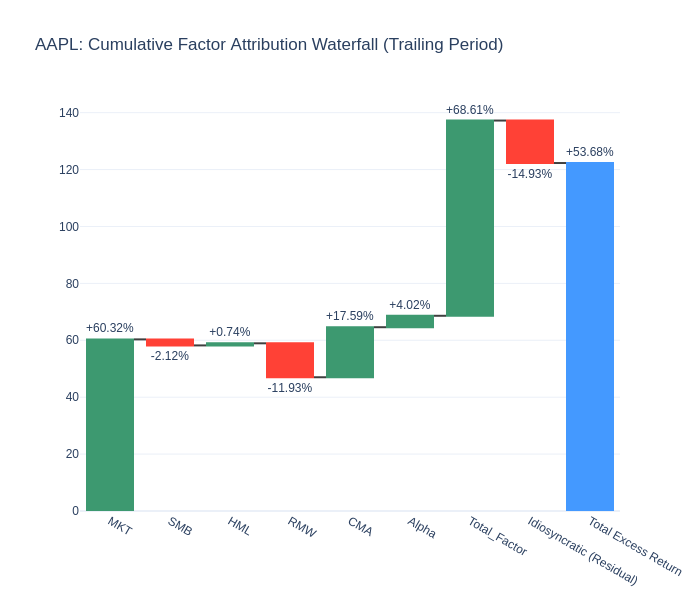

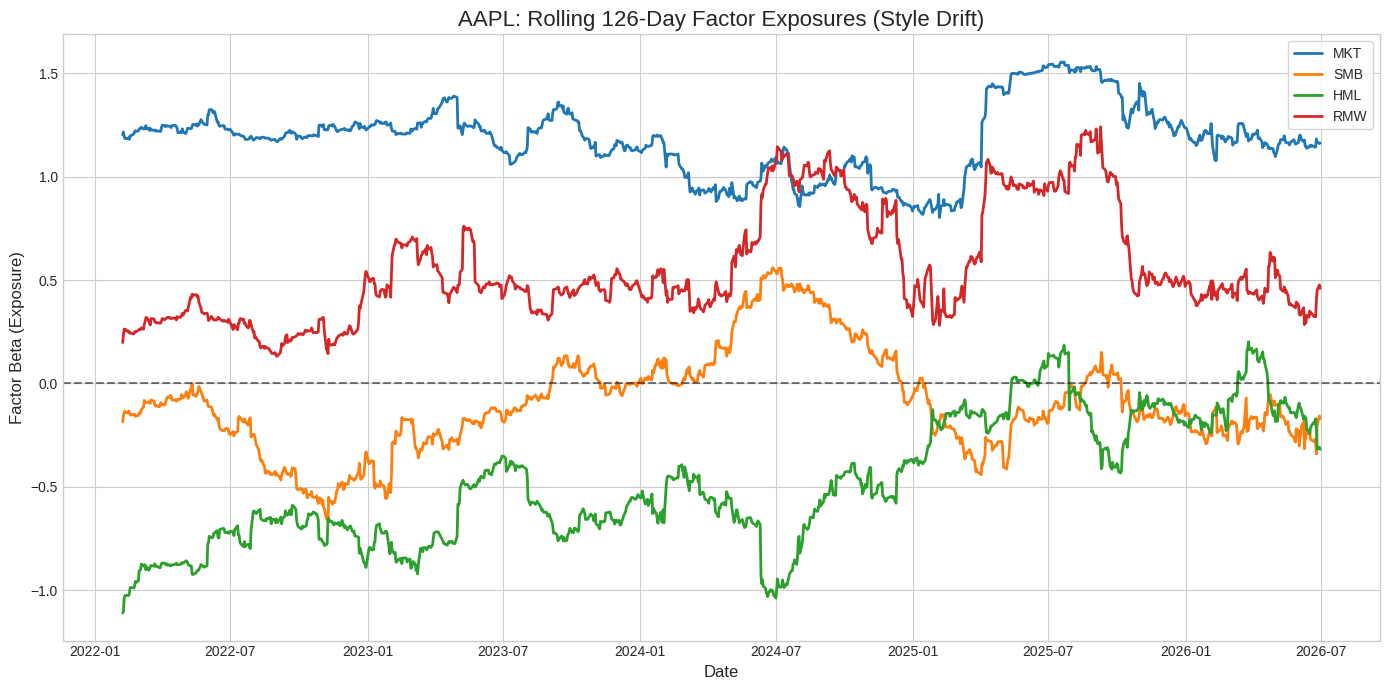

In [5]:
# CELL 5: Professional Visualizations & Dashboards

def plot_waterfall_attribution(attrib_df, ticker):
    total_contribs = attrib_df.sum()
    factors = [col for col in total_contribs.index if col.endswith('_Contrib')]
    values = total_contribs[factors].values * 100
    labels = [f.replace('_Contrib', '') for f in factors]

    factors.append('Residual')
    values = np.append(values, total_contribs['Residual'] * 100)
    labels.append('Idiosyncratic (Residual)')

    total_return = total_contribs['Excess_Return'] * 100

    fig = go.Figure(go.Waterfall(
        name="20", orientation="v",
        measure=["relative"] * len(labels) + ["total"],
        x=labels + ["Total Excess Return"],
        textposition="outside",
        text=[f"{v:+.2f}%" for v in values] + [f"{total_return:+.2f}%"],
        y=list(values) + [total_return],
        connector={"line":{"color":"rgb(63, 63, 63)"}},
    ))

    fig.update_layout(
        title=f"{ticker}: Cumulative Factor Attribution Waterfall (Trailing Period)",
        showlegend=False,
        template="plotly_white",
        height=600
    )
    fig.show(renderer="png")

def plot_rolling_betas(rolling_betas, ticker):
    plt.figure(figsize=(14, 7))

    plot_factors = ['MKT', 'SMB', 'HML', 'RMW']

    for factor in plot_factors:
        plt.plot(rolling_betas.index, rolling_betas[factor], label=factor, linewidth=2)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f"{ticker}: Rolling 126-Day Factor Exposures (Style Drift)", fontsize=16)
    plt.ylabel("Factor Beta (Exposure)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

plot_waterfall_attribution(attrib_aapl, 'AAPL')
plot_rolling_betas(rolling_betas_aapl, 'AAPL')

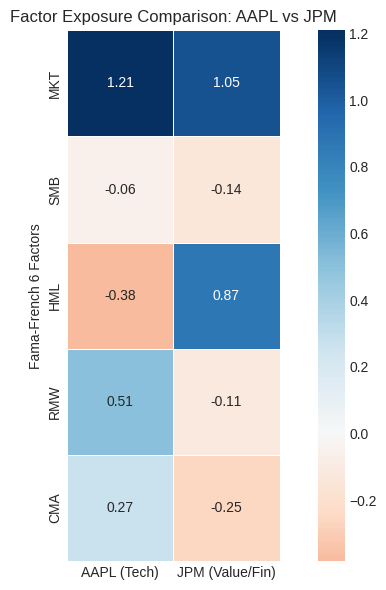


Conclusion:
Notice how AAPL typically has strong negative exposure to HML (Value) and positive to MKT (Beta).
Conversely, JPM demonstrates strong positive exposure to HML, correctly identifying it as a Value stock.


In [6]:
# CELL 6: Comparative Analysis (Tech vs Financials)
# Run the pipeline for JPM to compare exposures
modeler_jpm = FactorModeler(dataset, 'JPM')
static_res_jpm = modeler_jpm.static_regression()

# Extract parameters to a DataFrame for easy plotting
comparison_df = pd.DataFrame({
    'AAPL (Tech)': static_res_aapl.params,
    'JPM (Value/Fin)': static_res_jpm.params
}).drop('const')

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df, annot=True, cmap='RdBu', center=0, fmt='.2f', cbar=True,
            linewidths=.5, square=True)
plt.title('Factor Exposure Comparison: AAPL vs JPM')
plt.ylabel('Fama-French 6 Factors')
plt.tight_layout()
plt.show()

print("\nConclusion:")
print("Notice how AAPL typically has strong negative exposure to HML (Value) and positive to MKT (Beta).")
print("Conversely, JPM demonstrates strong positive exposure to HML, correctly identifying it as a Value stock.")